In [29]:
import json

path = "/content/EDA1.ipynb"  # 본인 파일 경로에 맞게 수정

with open(path, "r", encoding="utf-8") as f:
    nb = json.load(f)

if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open(path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print("완료")

완료


In [1]:
!pip install -q datasets pandas matplotlib seaborn wordcloud konlpy scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval
from scipy.stats import chi2_contingency, f_oneway
import re

plt.rcParams['font.family'] = 'NanumGothic'  # 한글 폰트
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

from datasets import load_dataset
ds = load_dataset("nvidia/Nemotron-Personas-Korea", split="train")
df = ds.to_pandas()
print(df.shape)
df.head(3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 15.2 MB/s eta 0:00:00


README.md:   0%|          | 0.00/36.0k [00:00<?, ?B/s]

data/train-00000-of-00009.parquet:   0%|          | 0.00/220M [00:00<?, ?B/s]

data/train-00001-of-00009.parquet:   0%|          | 0.00/220M [00:00<?, ?B/s]

data/train-00002-of-00009.parquet:   0%|          | 0.00/220M [00:00<?, ?B/s]

...

data/train-00007-of-00009.parquet:   0%|          | 0.00/220M [00:00<?, ?B/s]

data/train-00008-of-00009.parquet:   0%|          | 0.00/220M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

(1000000, 26)


,uuid,professional_persona,sports_persona,arts_persona,travel_persona,culinary_persona,family_persona,persona,cultural_background,skills_and_expertise,...,marital_status,military_status,family_type,housing_type,education_level,bachelors_field,occupation,district,province,country
0,03b4f36a18e6469386d0286dddd513c8,"전기태 씨는 광주 서구의 하역 현장에서 수십 년간 짐을 쌓아 올리며, 지렛대 원리를...","전기태 씨는 주말마다 무등산 자락을 느릿느릿 걸으며 땀을 흘리고, 내려오는 길에 단...",전기태 씨는 거실 소파에 깊숙이 파묻혀 텔레비전에서 나오는 옛날 가요 프로그램을 보...,전기태 씨는 아내와 함께 전국의 역사 유적지를 찾아다니며 옛 조상들의 발취를 느끼는...,전기태 씨는 일주일에 한 번 배달 짜장면과 탕수육을 시켜 먹는 날을 손꼽아 기다리며...,"전기태 씨는 전·월세 아파트에서 평생의 동반자인 아내와 단출하게 살아가며, 투박한 ...","전기태 씨는 광주 서구에서 평생 하역 일을 하며 살아온 70대 가장으로, 투박한 손...","광주 서구에서 평생을 보내며 투박하지만 정겨운 전라도 사투리가 몸에 배어 있고, 시...",수십 년간 하역 현장에서 다져진 감각으로 짐의 무게 중심을 한눈에 파악해 가장 효율...,...,배우자있음,비현역,배우자와 거주,아파트,초등학교,해당없음,하역 및 적재 관련 단순 종사원,광주-서구,광주,대한민국
1,73f75d42a3934626b0d9a4bff062715a,최은지 씨는 서초동 부동산 사무실에서 장부를 잡으며 복잡한 취득세나 양도세 계산을 ...,최은지 씨는 서초동 예술의전당 근처 산책로를 느릿하게 거닐며 동네 이웃들과 수다를 ...,"최은지 씨는 지역 문화센터의 서예 교실에서 붓을 잡으며 마음을 다스리지만, 쉬는 시...",최은지 씨는 가족들과 함께 경주 불국사의 다보탑이나 부여 낙화암의 절벽을 방문해 옛...,"최은지 씨는 일주일에 대여섯 번은 집 밖에서 식사를 해결하며, 나물 비빔밥이나 청국...",최은지 씨는 남편과 자녀들이 함께 사는 복작복작한 집안 분위기 속에서 가장 영향력 ...,최은지 씨는 서초구에서 부동산 회계 사무원으로 일하며 경제적 자립과 사교적인 삶을 ...,최은지는 서초구의 오래된 다세대 주택가에서 나고 자라며 체면과 질서를 중시하는 분위...,"복잡한 부동산 세금 계산이나 장부 정리를 빠르게 처리하며, 오랜 실무 경험을 바탕으...",...,배우자있음,비현역,배우자·자녀와 거주,다세대주택,4년제 대학교,자연과학·수학,회계 사무원,서울-서초구,서울,대한민국
2,89eca80b88284888ad94c84f56777680,"안상식 씨는 퇴직 후에도 목동 주민센터의 복잡한 서류 뭉치를 보며 흐뭇해하며, 동네...","안상식 씨는 정해진 시간에 집 근처 공원을 천천히 거닐며 나무의 상태를 살피고, 무...","안상식 씨는 나훈아의 구슬픈 가락을 거실에 작게 틀어놓고 멍하니 생각에 잠기거나, ...",안상식 씨는 고등학교 동창들과 함께 창덕궁의 후원을 천천히 걸으며 왕실의 기록을 살...,안상식 씨는 일주일에 한 번 가족들과 함께 동네 단골 한우집에서 육즙 가득한 갈비를...,안상식 씨는 말수 적은 할아버지로서 손주들에게 잔소리 대신 정직하게 살아온 뒷모습을...,"안상식 씨는 목동에서 평생을 성실함과 규칙으로 무장해 온, 꼼꼼한 가계부와 나훈아의...","양천구 목동의 오래된 아파트 단지에서 수십 년째 거주하며, 정해진 시간에 일어나 집...","가계부의 십 원 단위까지 정확하게 맞추고, 집안의 모든 중요 서류를 날짜와 항목별로...",...,배우자있음,비현역,배우자와 거주,아파트,고등학교,해당없음,무직,서울-양천구,서울,대한민국


1-1. 구조 파악 & 데이터 타입 확인

In [2]:
# 전체 컬럼, 타입, 메모리 확인
df.info()

# 컬럼별 데이터 타입 분류 (수치/범주/텍스트/리스트형)
def classify_column(col):
    if df[col].dtype in ['int64', 'float64']:
        return '수치형'
    sample = df[col].dropna().astype(str).iloc[0] if df[col].notna().any() else ""
    if sample.startswith('[') and sample.endswith(']'):
        return '리스트형(문자열)'
    avg_len = df[col].astype(str).str.len().mean()
    if avg_len > 50:
        return '장문 텍스트'
    elif df[col].nunique() < 50:
        return '범주형'
    else:
        return '준-범주형(고카디널리티)'

col_types = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'classified_type': [classify_column(c) for c in df.columns]
})
col_types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 26 columns):
 #   Column                      Non-Null Count    Dtype 
---  ------                      --------------    ----- 
 0   uuid                        1000000 non-null  object
 1   professional_persona        1000000 non-null  object
 2   sports_persona              1000000 non-null  object
 3   arts_persona                1000000 non-null  object
 4   travel_persona              1000000 non-null  object
 5   culinary_persona            1000000 non-null  object
 6   family_persona              1000000 non-null  object
 7   persona                     1000000 non-null  object
 8   cultural_background         1000000 non-null  object
 9   skills_and_expertise        1000000 non-null  object
 10  skills_and_expertise_list   1000000 non-null  object
 11  hobbies_and_interests       1000000 non-null  object
 12  hobbies_and_interests_list  1000000 non-null  object
 13  career_goals_

,dtype,n_unique,classified_type
uuid,object,1000000,준-범주형(고카디널리티)
professional_persona,object,1000000,장문 텍스트
sports_persona,object,1000000,장문 텍스트
arts_persona,object,1000000,장문 텍스트
travel_persona,object,1000000,장문 텍스트
culinary_persona,object,1000000,장문 텍스트
family_persona,object,1000000,장문 텍스트
persona,object,1000000,장문 텍스트
cultural_background,object,1000000,장문 텍스트
skills_and_expertise,object,999999,장문 텍스트


1-2. 결측치 / 오류 탐지

In [5]:
# 결측치 비율
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'결측수': missing, '결측률(%)': missing_pct})
print(missing_df[missing_df['결측수'] > 0])

# 논리적 N/A 확인 (예: 학사 이하 학력에서 bachelors_field='해당없음' 등)
if 'bachelors_field' in df.columns:
    print(df['bachelors_field'].value_counts())

# 리스트형 컬럼 파싱 & 손상 여부 점검
list_cols = [c for c in df.columns if df[c].astype(str).str.startswith('[').any()]
for c in list_cols:
    def safe_parse(x):
        try:
            return literal_eval(x)
        except Exception:
            return None
    parsed = df[c].astype(str).apply(safe_parse)
    n_fail = parsed.isnull().sum()
    print(f"[{c}] 파싱 실패 건수: {n_fail} / {len(df)}")

# 중복 uuid, 중복 레코드 확인
print("중복 uuid:", df['uuid'].duplicated().sum())
print("완전 중복 행:", df.duplicated().sum())

# 이상치 후보 (age 범위)
print("age 범위:", df['age'].min(), "~", df['age'].max())
print("19세 미만 존재 여부:", (df['age'] < 19).sum())

Empty DataFrame
Columns: [결측수, 결측률(%)]
Index: []
bachelors_field
해당없음        674421
공학·제조·건설     67871
경영·행정·법      54913
예술·인문        49031
보건·복지        34547
교육           31498
정보통신기술       29169
서비스          18438
사회과학·언론      17219
자연과학·수학      16949
농림어업·수의학      5944
Name: count, dtype: int64
[skills_and_expertise_list] 파싱 실패 건수: 0 / 1000000
[hobbies_and_interests_list] 파싱 실패 건수: 0 / 1000000
중복 uuid: 0
완전 중복 행: 0
age 범위: 19 ~ 99
19세 미만 존재 여부: 0


1-3. 분포 검증 (KOSIS 상식 대비)

In [6]:
# 연령 분포
print(df['age'].describe())

# 연령대 그룹핑
bins = [18, 24, 34, 44, 54, 64, 74, 84, 100]
labels = ['19-24','25-34','35-44','45-54','55-64','65-74','75-84','85+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
age_dist = df['age_group'].value_counts(normalize=True).sort_index() * 100
print(age_dist)

# 성비, 혼인상태, 학력 등 기본 분포
for col in ['sex', 'marital_status', 'education_level', 'housing_type', 'family_type']:
    print(f"\n=== {col} 분포 ===")
    print(df[col].value_counts(normalize=True).head(10) * 100)

# 지역 분포 (province 기준)
print(df['province'].value_counts(normalize=True) * 100)

count    1000000.000000
mean          50.660031
std           17.612993
min           19.000000
25%           36.000000
50%           51.000000
75%           64.000000
max           99.000000
Name: age, dtype: float64
age_group
19-24     7.0204
25-34    15.4249
35-44    15.9537
45-54    18.8077
55-64    19.3794
65-74    13.7695
75-84     7.2495
85+       2.3949
Name: proportion, dtype: float64

=== sex 분포 ===
sex
여자    50.4442
남자    49.5558
Name: proportion, dtype: float64

=== marital_status 분포 ===
marital_status
배우자있음    59.2538
미혼       25.6962
사별        8.7888
이혼        6.2612
Name: proportion, dtype: float64

=== education_level 분포 ===
education_level
고등학교          33.1377
4년제 대학교       27.1256
2~3년제 전문대학    15.0235
중학교            8.5255
초등학교           8.1239
대학원            5.4323
무학             2.6315
Name: proportion, dtype: float64

=== housing_type 분포 ===
housing_type
아파트             62.0556
단독주택            16.9153
다세대주택           11.4369
주택 이외의 거처        6.0264
연립주택          

2단계: 개별 속성값 관찰 (Univariate Analysis)

2-1. 수치형(age) 상세 통계 + 아웃라이어

평균: 50.660031
중앙값: 51.0
표준편차: 17.61299288300505
왜도: 0.11755319051911993
사분위수: 0.25    36.0
0.50    51.0
0.75    64.0
Name: age, dtype: float64


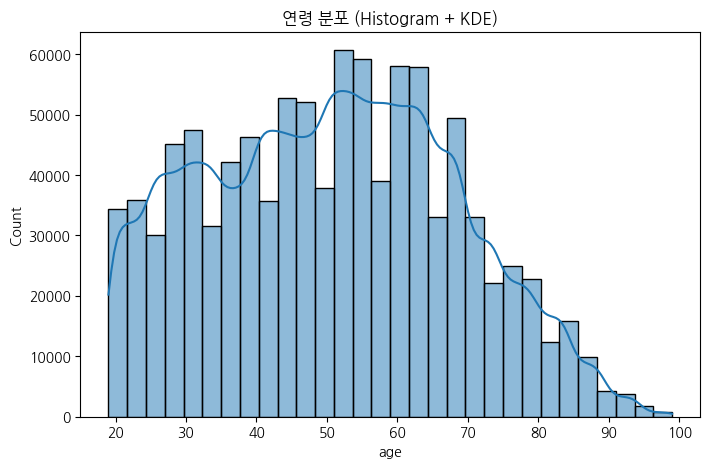

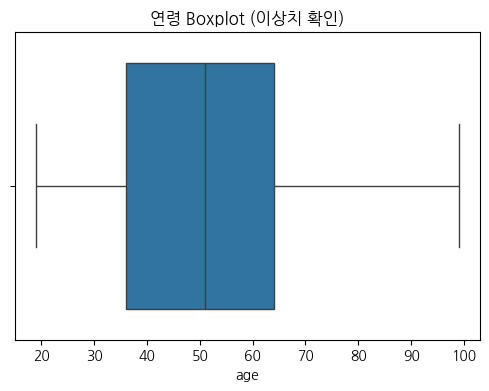

In [7]:
print("평균:", df['age'].mean())
print("중앙값:", df['age'].median())
print("표준편차:", df['age'].std())
print("왜도:", df['age'].skew())
print("사분위수:", df['age'].quantile([0.25, 0.5, 0.75]))

# 히스토그램
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('연령 분포 (Histogram + KDE)')
plt.show()

# 박스플롯으로 이상치 확인
plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'])
plt.title('연령 Boxplot (이상치 확인)')
plt.show()

2-2. 범주형 변수 빈도 분포 시각화

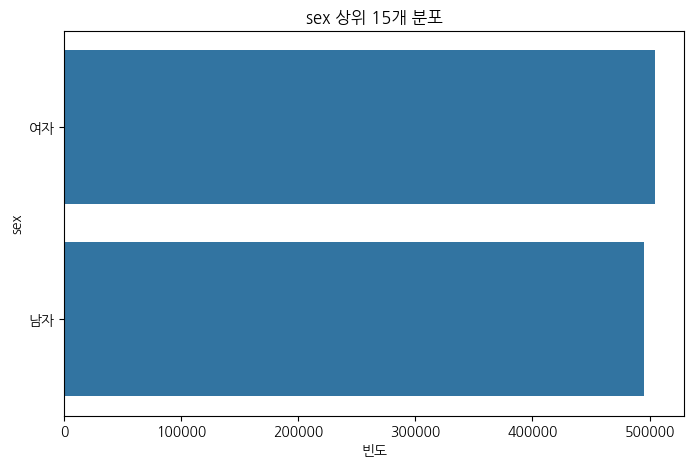

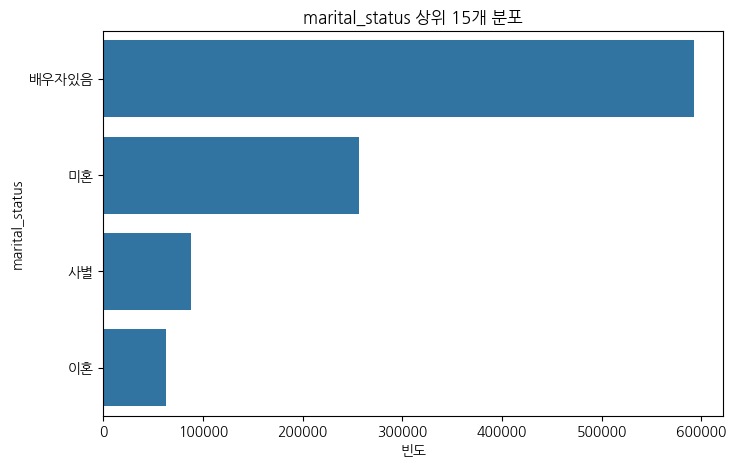

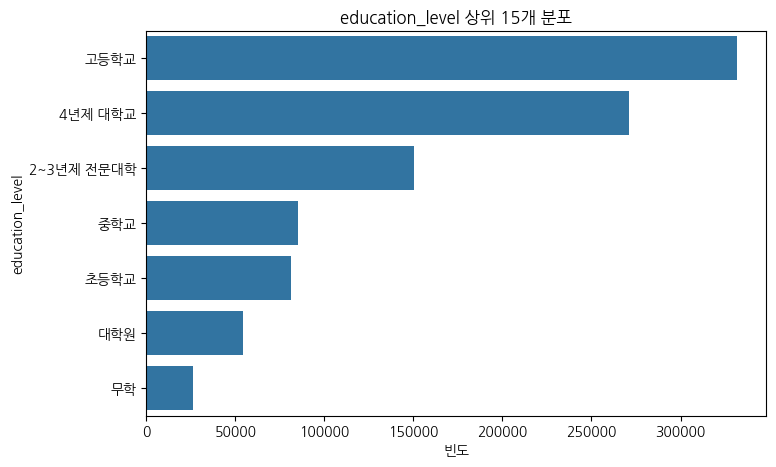

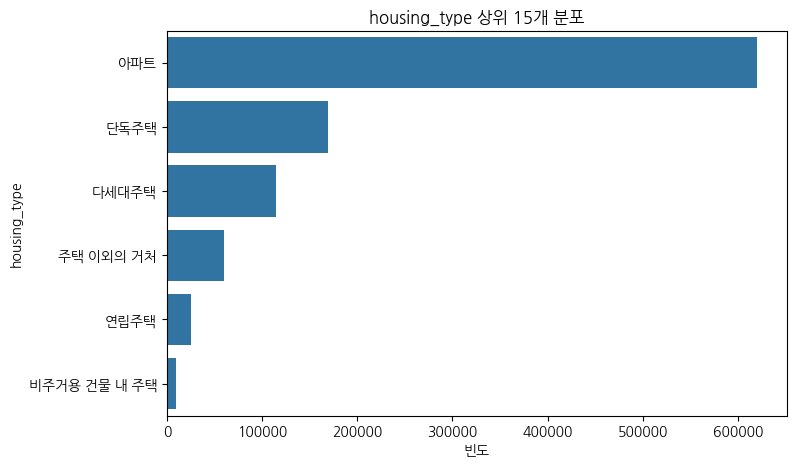

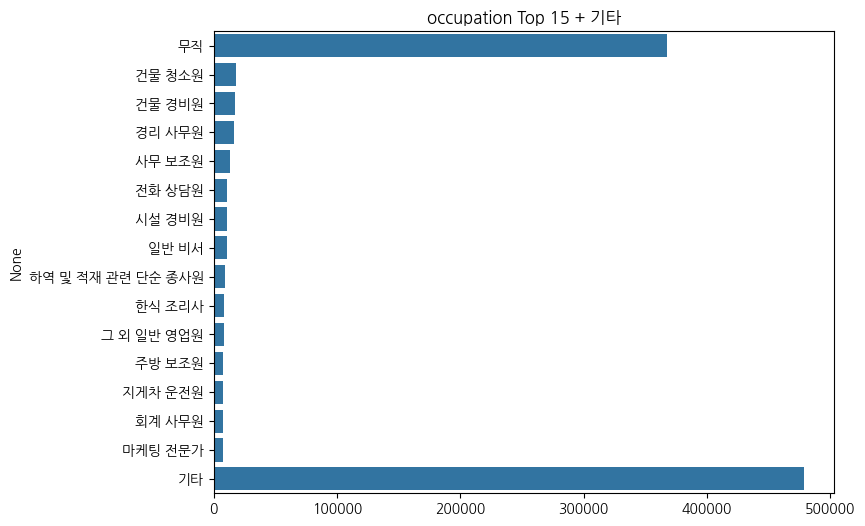

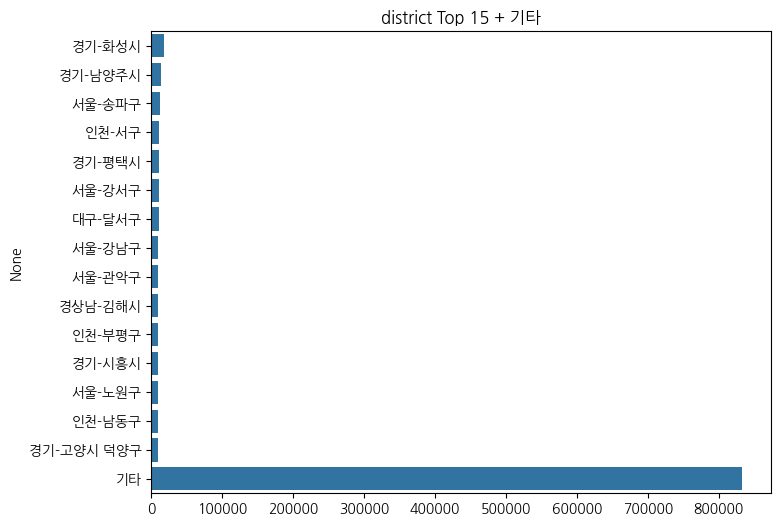

occupation 엔트로피: 6.291732928724553
district 엔트로피: 7.527129876782713


In [8]:
def plot_category(col, top_n=15):
    counts = df[col].value_counts().head(top_n)
    plt.figure(figsize=(8,5))
    sns.barplot(x=counts.values, y=counts.index, orient='h')
    plt.title(f'{col} 상위 {top_n}개 분포')
    plt.xlabel('빈도')
    plt.show()

for col in ['sex', 'marital_status', 'education_level', 'housing_type']:
    plot_category(col)

# 고카디널리티 변수(occupation, district)는 Top-N + 기타 처리
def plot_category_with_etc(col, top_n=15):
    counts = df[col].value_counts()
    top = counts.head(top_n)
    etc = pd.Series({'기타': counts.iloc[top_n:].sum()})
    combined = pd.concat([top, etc])
    plt.figure(figsize=(8,6))
    sns.barplot(x=combined.values, y=combined.index, orient='h')
    plt.title(f'{col} Top {top_n} + 기타')
    plt.show()

plot_category_with_etc('occupation')
plot_category_with_etc('district')

# 다양성(엔트로피) 측정
def shannon_entropy(series):
    p = series.value_counts(normalize=True)
    return -np.sum(p * np.log2(p))

print("occupation 엔트로피:", shannon_entropy(df['occupation']))
print("district 엔트로피:", shannon_entropy(df['district']))

2-3. 텍스트 필드 관찰 (길이 분포, 형태소 빈도, 워드클라우드)

In [13]:
# 분석용 서브샘플을 맨 위에서 한 번만 생성 (이후 모든 셀에서 재사용)
SAMPLE_N = 20000
df_sample = df.sample(SAMPLE_N, random_state=42).reset_index(drop=True)

In [14]:
import re
from collections import Counter

def simple_tokenize(text_series, sample_size=20000):
    sample = text_series.dropna().sample(min(sample_size, len(text_series)), random_state=42)
    all_words = []
    for t in sample:
        words = re.findall(r'[가-힣]{2,}', str(t))  # 2글자 이상 한글 어절만 추출
        all_words.extend(words)
    return Counter(all_words)

word_counts = simple_tokenize(df_sample['persona'])
top_words = pd.Series(dict(word_counts.most_common(30)))
print(top_words)

씨는       20004
여성입니다     5155
소박한       3646
가장입니다     3064
삶의        2598
동시에       2585
찾는        2534
일하며       2274
남성입니다     2129
살아가는      2060
꿈꾸는       1936
대한        1924
통해        1907
꼼꼼한       1877
균형을       1831
건강        1790
소소한       1755
가진        1737
가족의       1685
성실하게      1684
속에서       1661
거주하며      1655
가족과       1595
일상의       1548
청년입니다     1535
갖춘        1360
사이에서      1358
예술적       1345
성격의       1339
성실한       1287
dtype: int64


3단계: 속성 간의 관계 분석 (Multivariate Analysis)

3-1. 연령대 × 범주형 변수 (Stacked Bar Chart)

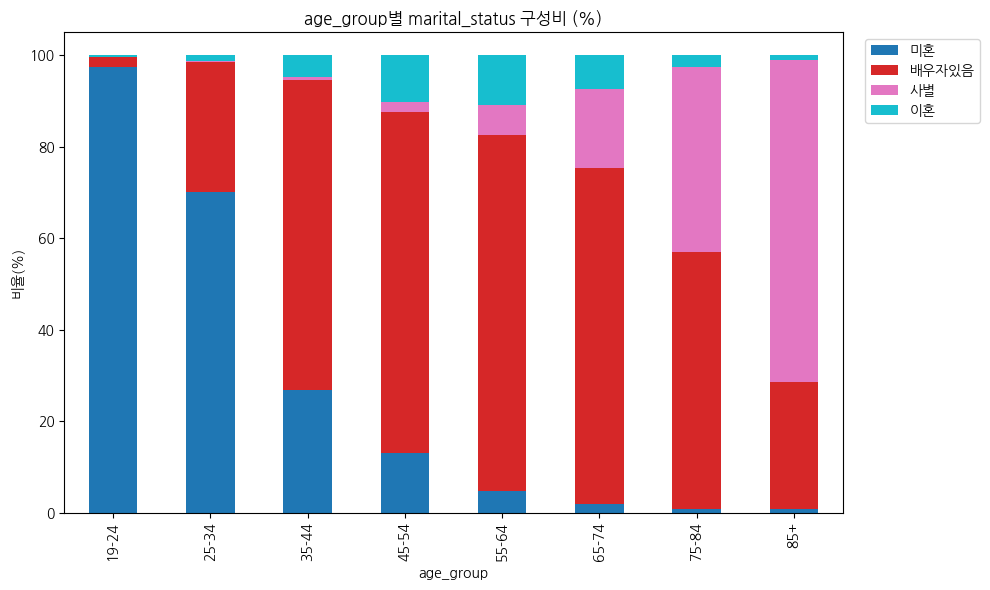

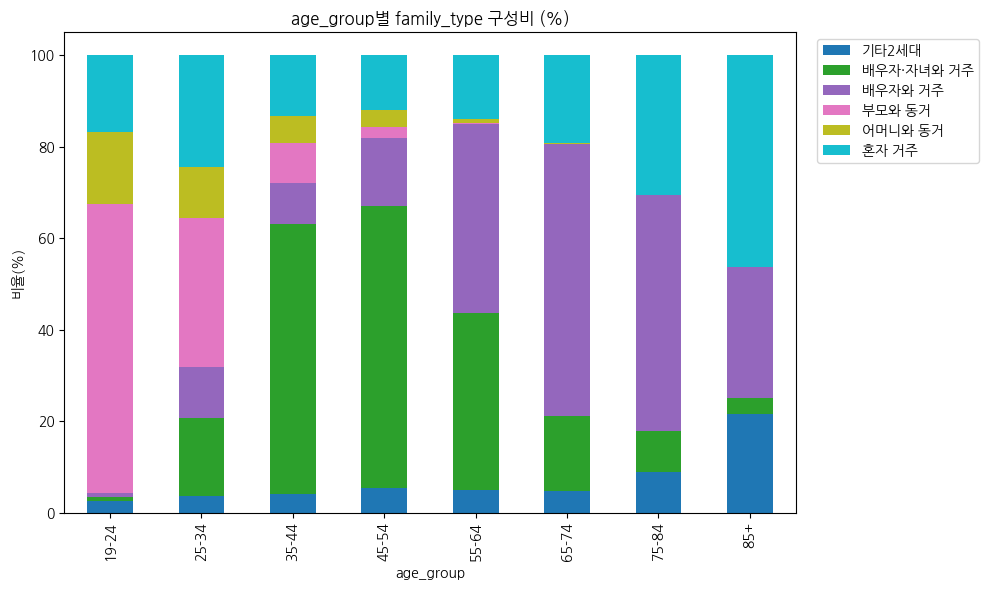

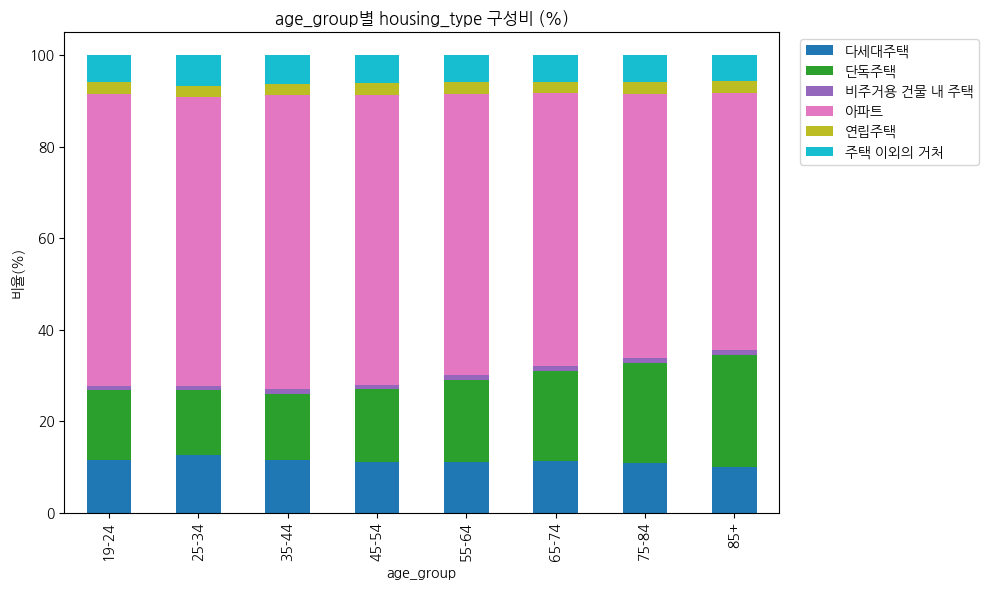

In [15]:
def stacked_bar(group_col, target_col, top_n=6):
    top_cats = df[target_col].value_counts().head(top_n).index
    sub = df[df[target_col].isin(top_cats)]
    ct = pd.crosstab(sub[group_col], sub[target_col], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab10')
    plt.title(f'{group_col}별 {target_col} 구성비 (%)')
    plt.ylabel('비율(%)')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

stacked_bar('age_group', 'marital_status')
stacked_bar('age_group', 'family_type')
stacked_bar('age_group', 'housing_type')

3-2. 지역 × 학력/직업 교차분석

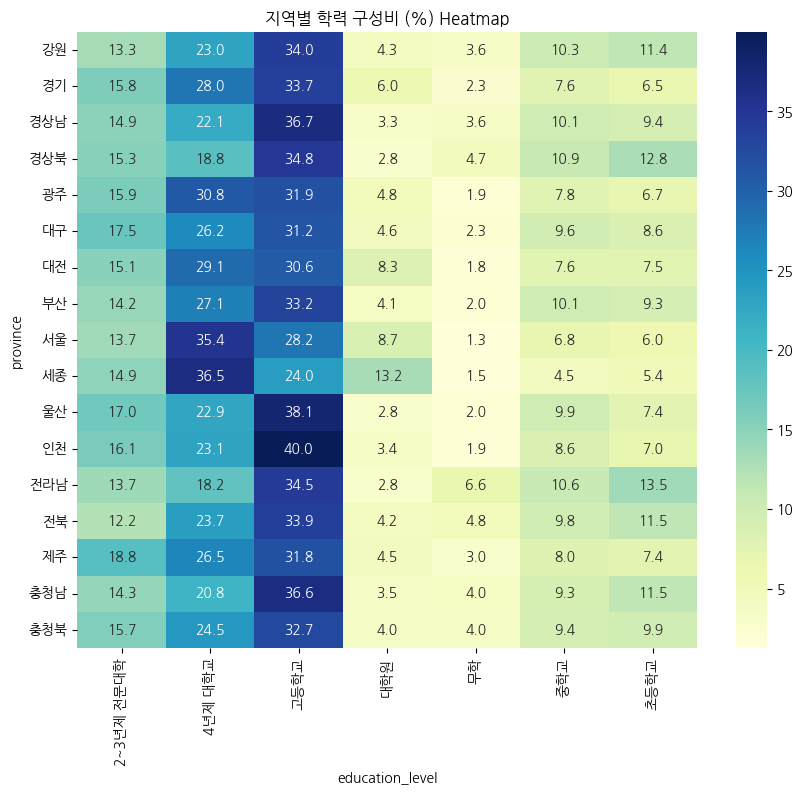

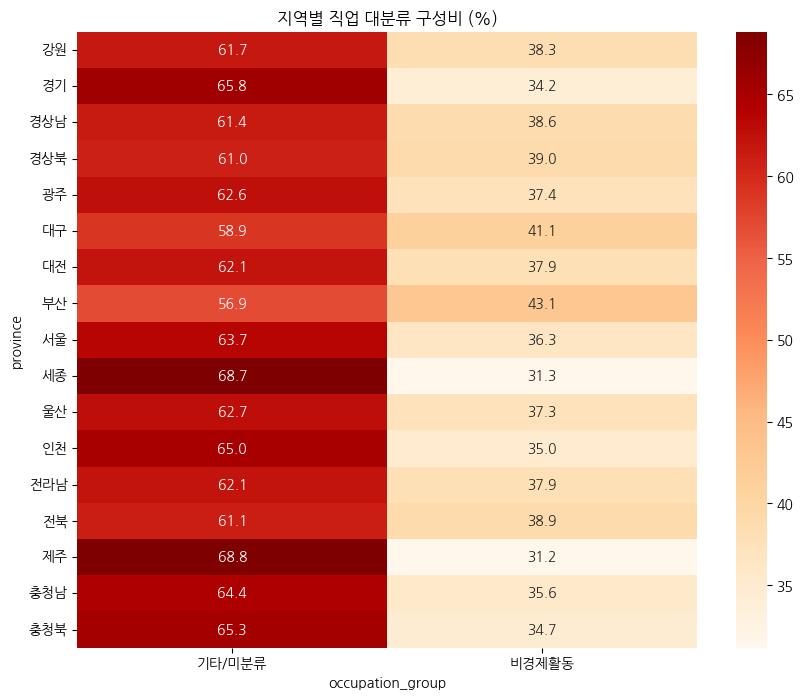

In [16]:
# 지역별 학력 구성 (Heatmap)
edu_by_region = pd.crosstab(df['province'], df['education_level'], normalize='index') * 100
plt.figure(figsize=(10,8))
sns.heatmap(edu_by_region, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('지역별 학력 구성비 (%) Heatmap')
plt.show()

# 직업 대분류 매핑 (필요시 사전 정의)
occupation_map = {
    '온라인쇼핑판매원': '판매/서비스', '무직': '비경제활동',
    # ... 실제 고유값 확인 후 매핑 테이블 확장 필요
}
df['occupation_group'] = df['occupation'].map(occupation_map).fillna('기타/미분류')

occ_by_region = pd.crosstab(df['province'], df['occupation_group'], normalize='index') * 100
plt.figure(figsize=(10,8))
sns.heatmap(occ_by_region, annot=True, fmt='.1f', cmap='OrRd')
plt.title('지역별 직업 대분류 구성비 (%)')
plt.show()

3-3. 통계적 연관성 검정

In [17]:
# (1) 연속형(age) vs 범주형: ANOVA
groups = [df[df['marital_status']==cat]['age'].dropna() for cat in df['marital_status'].unique()]
f_stat, p_val = f_oneway(*groups)
print(f"marital_status별 age 차이 ANOVA: F={f_stat:.2f}, p={p_val:.4f}")

# (2) 범주형 vs 범주형: 카이제곱 + Cramér's V
def cramers_v(col1, col2):
    ct = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    v = np.sqrt(phi2 / min(k-1, r-1))
    return chi2, p, v

for pair in [('education_level', 'housing_type'),
             ('family_type', 'housing_type'),
             ('marital_status', 'family_type')]:
    chi2, p, v = cramers_v(*pair)
    print(f"{pair}: chi2={chi2:.1f}, p={p:.4f}, Cramér's V={v:.3f}")

marital_status별 age 차이 ANOVA: F=290040.79, p=0.0000
('education_level', 'housing_type'): chi2=8804.7, p=0.0000, Cramér's V=0.042
('family_type', 'housing_type'): chi2=4294.4, p=0.0000, Cramér's V=0.029
('marital_status', 'family_type'): chi2=1443261.9, p=0.0000, Cramér's V=0.694


3-4. 텍스트 × 정형변수: 그룹별 키워드 차별성 (로그오즈비 근사)

In [20]:
import re
from collections import Counter

def simple_nouns(text):
    # 형태소 분석기 대신 2글자 이상 한글 어절 추출 (Okt 대비 수십 배 빠름)
    return re.findall(r'[가-힣]{2,}', str(text))

def group_keyword_diff(text_col, group_col, group_a, group_b, top_n=15, sample_size=3000):
    # 그룹별로 샘플링 먼저 (전체 넣지 않기)
    text_a = df[df[group_col]==group_a][text_col].dropna().astype(str)
    text_b = df[df[group_col]==group_b][text_col].dropna().astype(str)

    text_a = text_a.sample(min(sample_size, len(text_a)), random_state=42)
    text_b = text_b.sample(min(sample_size, len(text_b)), random_state=42)

    # Counter로 빠르게 집계 (Okt 없이)
    counts_a = Counter(w for t in text_a for w in simple_nouns(t))
    counts_b = Counter(w for t in text_b for w in simple_nouns(t))

    nouns_a = pd.Series(counts_a)
    nouns_b = pd.Series(counts_b)

    # pandas 벡터 연산으로 로그오즈비 계산 (for문 제거)
    df_ratio = pd.DataFrame({'a': nouns_a, 'b': nouns_b}).fillna(0)
    df_ratio = df_ratio[(df_ratio['a'] >= 3) | (df_ratio['b'] >= 3)]  # 너무 희귀한 단어 제외
    a_freq = df_ratio['a'] / df_ratio['a'].sum()
    b_freq = df_ratio['b'] / df_ratio['b'].sum()
    df_ratio['log_odds'] = np.log((a_freq + 1e-6) / (b_freq + 1e-6))

    result = df_ratio['log_odds'].sort_values(ascending=False)
    print(f"[{group_a} 특징 단어 Top {top_n}]")
    print(result.head(top_n))
    print(f"\n[{group_b} 특징 단어 Top {top_n}]")
    print(result.tail(top_n))

    return result

# 실행
result = group_keyword_diff('hobbies_and_interests', 'age_group', '19-24', '65-74')

[19-24 특징 단어 Top 15]
뉴진스의       7.731243
네이버        7.412954
정주행하거나     7.236614
넷플릭스       6.931489
플레이리스트를    6.931489
웹툰의        6.931489
랭크         6.818278
시리즈를       6.818278
인디         6.804870
침대         6.734991
아이돌        6.720410
게임         6.720410
소금빵        6.659861
웹툰         6.544186
부모님과       6.526512
Name: log_odds, dtype: float64

[65-74 특징 단어 Top 15]
손주들이    -6.265396
자녀들의    -6.354181
막걸리     -6.415953
상식      -6.435723
옛이야기를   -6.492792
자녀들이    -6.529106
자녀들과    -6.646727
파마를     -6.766126
친목회     -6.807464
나훈아의    -6.934084
친목      -7.067494
흘러나오는   -7.118224
라디오에서   -7.185182
트로트     -8.093585
임영웅의    -8.442680
Name: log_odds, dtype: float64


3-5. 가구유형 전이 흐름 (Sankey Diagram)

In [21]:
!pip install -q plotly
import plotly.graph_objects as go

# 연령대 -> 가구유형 흐름 데이터 구성
flow = df.groupby(['age_group', 'family_type']).size().reset_index(name='count')
flow = flow.sort_values('count', ascending=False).head(30)  # 주요 흐름만

age_groups = flow['age_group'].unique().tolist()
family_types = flow['family_type'].unique().tolist()
labels = list(age_groups) + list(family_types)

source = flow['age_group'].apply(lambda x: labels.index(x))
target = flow['family_type'].apply(lambda x: labels.index(x) )
target = target + len(age_groups)  # offset 보정 필요시 재계산

fig = go.Figure(data=[go.Sankey(
    node=dict(label=labels, pad=15, thickness=20),
    link=dict(source=source, target=target, value=flow['count'])
)])
fig.update_layout(title_text="연령대별 가구유형 전이 흐름", font_size=10)
fig.show()

/tmp/ipykernel_8691/1560773505.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  flow = df.groupby(['age_group', 'family_type']).size().reset_index(name='count')


마무리: 요약 리포트 자동 생성

In [22]:
summary = {
    '전체 레코드 수': len(df),
    '컬럼 수': df.shape[1],
    '결측치 존재 컬럼 수': (df.isnull().sum() > 0).sum(),
    '연령 평균/중앙값': f"{df['age'].mean():.1f} / {df['age'].median()}",
    'occupation 고유값 수': df['occupation'].nunique(),
    'district 고유값 수': df['district'].nunique(),
}
pd.Series(summary)

,0
전체 레코드 수,1000000
컬럼 수,33
결측치 존재 컬럼 수,0
연령 평균/중앙값,50.7 / 51.0
occupation 고유값 수,2120
district 고유값 수,252
